# STAT109 Lab 4 — Demo Notebook

Two key examples:
1. **Bayes’ Rule via simulation**
2. **Coin toss & Binomial functions** (includes `dbinom`, `pbinom`, `rbinom`, simulation, and **simple ggplot bars**)


## New R functions in Lab 4 (since Labs 1–3)

### Counting / combinatorics
- `factorial(n)` — compute n!
- `prod(1:n)` — multiply a sequence (another way to compute n!)
- `choose(n, k)` — combinations

### Binomial (Coin Toss) distribution
- `dbinom(x, size = n, prob = p)` — $P(X=x)$
- `pbinom(q, size = n, prob = p)` — $P(X \leq x)$ or change the "tail"
- `rbinom(n_sims, size = n, prob = p)` — simulate numbers of "heads" in $n$ tosses if the probability of a single head in one toss is `p`

### Plotting helpers
- `ggplot` - need to load the library for making plots
- `aes` - map between the names of variables in the data and elements you can see on the plot, e.g. `aes(x=mycategories)` means plot the values in the dataset for the variable named `mycategories` on the `x` axis.
- `geom_bar()` - add some "bar" geometry to an existing ggplot
- `after_stat(counts)` — in `geom_bar()`, plot *counts* of the categories in the $x$ variable
- `after_stat(prop)` — in `geom_bar()`, plot *proportions* instead of counts
- `geom_vline(xintercept=...)` — add a vertical reference line
- `geom_col()` — draw bars from a data frame you already computed (we’ll use this for `dbinom`)


## Setup

**Desired output:** Load tidyverse and set a random seed.

In [ ]:
20/64

[1] 0.3125

In [ ]:
# nPr n!/(n-r)!
factorial(6)/factorial(6-3)/factorial(3)

[1] 20

In [ ]:
# combination = choose, nCk = nPk/k!
choose(n=6, k=3)

[1] 20

In [ ]:
choose(25, 20)

[1] 53130

In [ ]:
factorial(3)

[1] 6

In [ ]:
pbinom(q=3, size = 6, prob= 0.25)

[1] 0.9624023

In [ ]:
pbinom(q=3, size = 6, prob= 0.25, lower.tail=FALSE)

[1] 0.03759766

In [ ]:
library(tidyverse) # need this to run ggplot2 code
set.seed(109)


## Example 1 — Bayes’ Rule via simulation

A screening test has:
- prevalence: $P(D) = 1/800$
- sensitivity: $P(T^+\mid D)=0.980$
- specificity: $P(T^-\mid D^c)=0.995$

**Desired output:**
1. Simulate disease status
2. Simulate test results conditional on disease status
3. Compute from simulation: $P(D\mid T^+)$
4. Compute using Bayes’ rule formula


In [ ]:
population_size <- 1000
prevalence <- 1/800
sensitivity <- 0.980
specificity <- 0.995

set.seed(109)

# 1) Disease status: 1 = disease, 0 = no disease
disease <- sample(
  x = c(0, 1),
  size = population_size,
  replace = TRUE,
  prob = c(1 - prevalence, prevalence)
)

# 2) Test result: 1 = positive, 0 = negative
test <- vector("numeric", population_size)

for(i in 1:population_size){
  if(disease[i] == 1){
    # With disease: positive with prob = sensitivity
    test[i] <- sample(c(0, 1), size = 1, prob = c(1 - sensitivity, sensitivity))
  } else {
    # Without disease: positive with prob = 1 - specificity (false positive)
    test[i] <- sample(c(0, 1), size = 1, prob = c(specificity, 1 - specificity))
  }
}

# 3) PPV from simulation: P(D=1 | T=1)
ppv_sim <- sum(disease[test == 1] == 1) / sum(test == 1)
ppv_sim

# 4) PPV from Bayes' rule
ppv_formula <- (sensitivity * prevalence) / ((sensitivity * prevalence) + ((1 - specificity) * (1 - prevalence)))
ppv_formula


[1] 0.2

[1] 0.1969849

## Example 2 — Coin toss & Binomial functions (n = 6)

Let \(X\) = number of heads in \(n=6\) tosses.

We’ll compare a **fair coin** (p = 0.5) and a **biased coin** (p = 0.7).


In [ ]:
factorial(5)

[1] 120

In [ ]:
prod(1:5)
1*2*3*4*5

[1] 120

[1] 120

In [ ]:
factorial(26)/factorial(24)
26*25

[1] 650

[1] 650

In [ ]:
# calculate nPk
n=26
k=2
factorial(n)/factorial(n-k)

[1] 650

Coin Tosses

n= 6 tosses
3 to be heads

Combination = number of ways to choose k things from n things when the order of the k things doesn't matter
nCk = "choose" in R

### A) Combinations check

**Desired output:** Compute \(\binom{6}{3}\) three ways: `choose`, factorial formula, and show `factorial` vs `prod` for \(6!\).

In [ ]:
factorial(6)
prod(1:6)

choose(6, 3)

n <- 6
k <- 3
factorial(n) / (factorial(k) * factorial(n - k))


[1] 720

[1] 720

[1] 20

[1] 20

### B) `dbinom`: exactly 3 heads

**Desired output:** Compute `P(X = 3)` for p = 0.5 and p = 0.7.

In [ ]:
n <- 6
x <- 3

dbinom(x, size = n, prob = 0.5)
dbinom(x, size = n, prob = 0.7)


[1] 0.3125

[1] 0.18522

### C) `pbinom`: at most / at least

**Desired output:** For each p (0.5 and 0.7), compute:
- `P(X <= 3)` using `pbinom(3, ...)`
- `P(X >= 3)` using `pbinom(2, ..., lower.tail = FALSE)`


In [ ]:
n <- 6

# Fair coin
p <- 0.5
pbinom(3, size = n, prob = p)                       # P(X <= 3)
pbinom(2, size = n, prob = p, lower.tail = FALSE)   # P(X >= 3)

# Biased coin
p <- 0.7
pbinom(3, size = n, prob = p)
pbinom(2, size = n, prob = p, lower.tail = FALSE)


[1] 0.65625

[1] 0.65625

[1] 0.25569

[1] 0.92953

### D) `rbinom`: simulate X directly

**Desired output:** Simulate 10,000 values of X and estimate `P(X = 3)`; compare to `dbinom(3, ...)`. Do it for p = 0.5 and p = 0.7.

In [ ]:
rbinom(n = 2, size=6, prob=0.5)

[1] 3 4

In [ ]:
n <- 6
reps <- 10000

# Fair
p <- 0.5
x_sim <- rbinom(n = reps, size = n, prob = p)
mean(x_sim == 3)
dbinom(3, size = n, prob = p)

[1] 0.3138

[1] 0.3125

In [ ]:
n <- 6
reps <- 10000

# Fair
p <- 0.5
x_sim <- rbinom(n = reps, size = n, prob = p)
mean(x_sim == 3)
dbinom(3, size = n, prob = p)

# Biased
p <- 0.7
x_sim <- rbinom(n = reps, size = n, prob = p)
mean(x_sim == 3)
dbinom(3, size = n, prob = p)


[1] 0.3136

[1] 0.3125

[1] 0.1839

[1] 0.18522

### E) Simulate tosses using a `for` loop + `sample()`

**Desired output:** Simulate 10,000 experiments of 6 tosses for a fair coin and store the number of heads each time.

In [ ]:
set.seed(109)

n <- 6
reps <- 10000
x <- vector("numeric", reps)

for(i in 1:reps){
  tosses <- sample(c("H","T"), size = n, replace = TRUE)
  x[i] <- sum(tosses == "H")
}

data <- data.frame(heads = x)
head(data)


,heads
,<dbl>
1,2
2,3
3,3
4,1
5,4
6,4


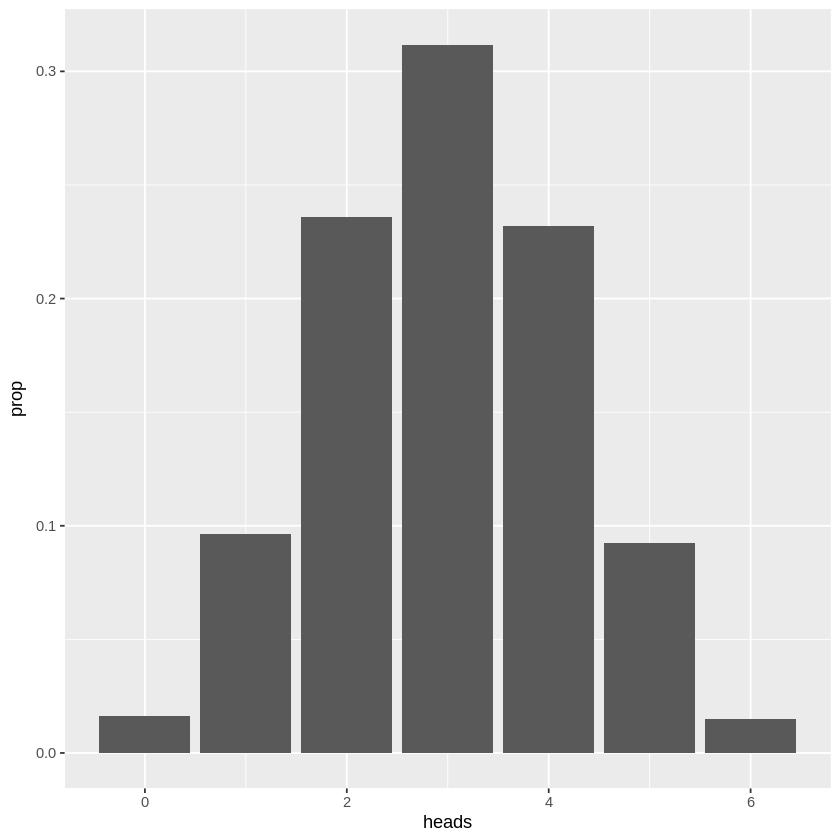

In [ ]:
ggplot(data, aes(x=heads, y=after_stat(prop)))+
  geom_bar()

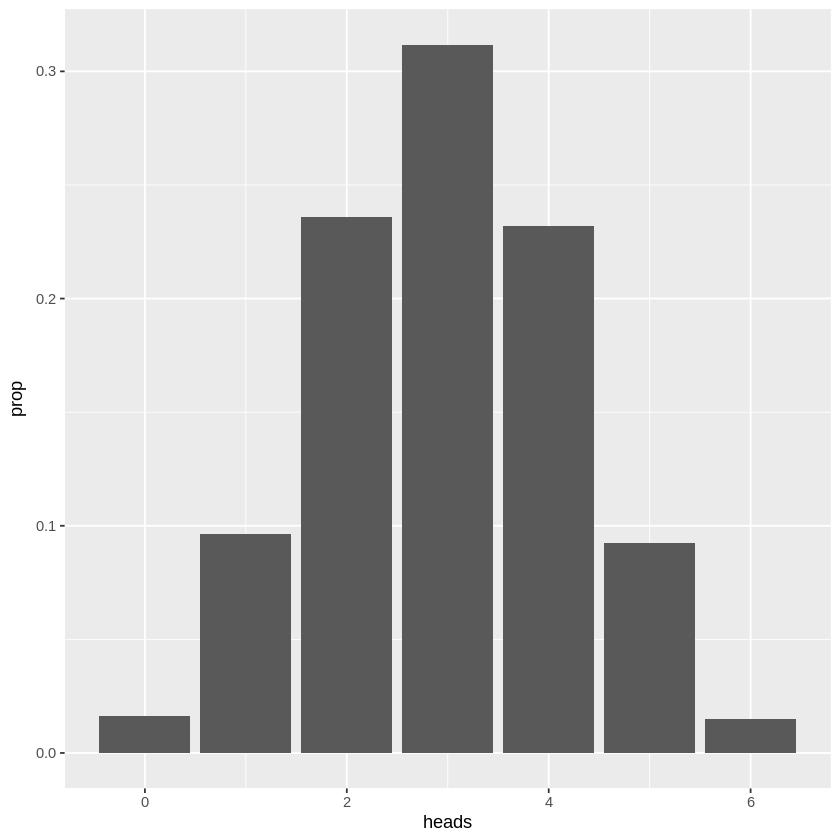

In [ ]:
ggplot(data, aes(x=heads, y=after_stat(prop)))+
  geom_bar()

### F) Plot counts (simple bar chart)

**Desired output:** A bar plot with heights = *counts* of 0,1,2,...,6 heads.

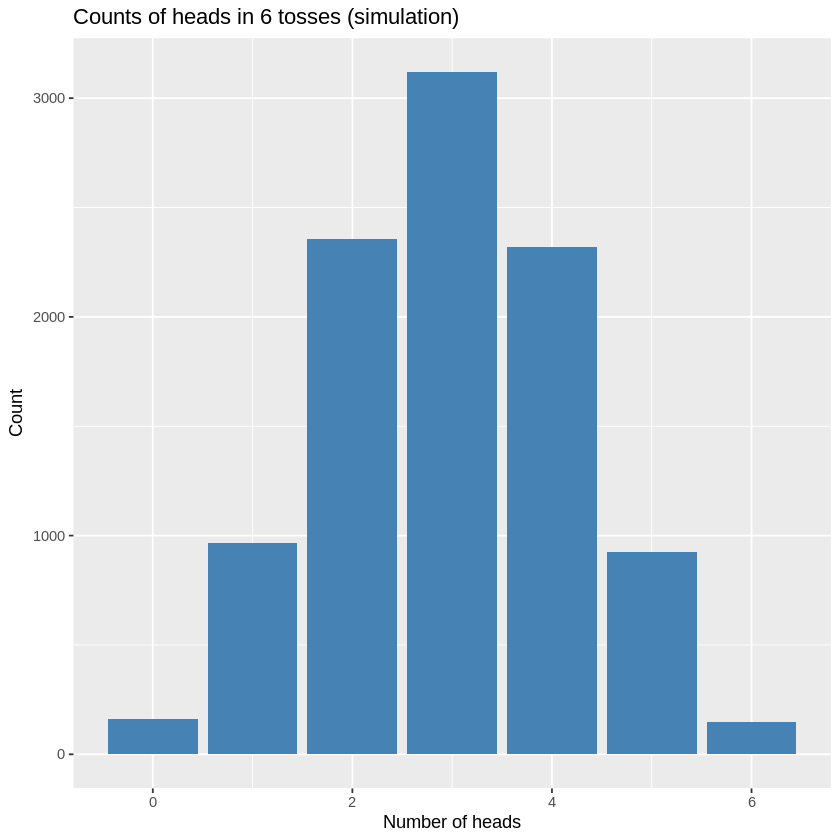

In [ ]:
ggplot(data, aes(x = heads)) +
  geom_bar(fill = "steelblue") +
  labs(
    title = "Counts of heads in 6 tosses (simulation)",
    x = "Number of heads",
    y = "Count"
  )


### G) Plot proportions + overlay `dbinom` as bars (alpha)

**Desired output:**
- Blue bars: simulated *proportions* using `after_stat(prop)`
- Red bars: true Bin(6, 0.5) probabilities from `dbinom`
- Add a dashed vertical line at x = 3


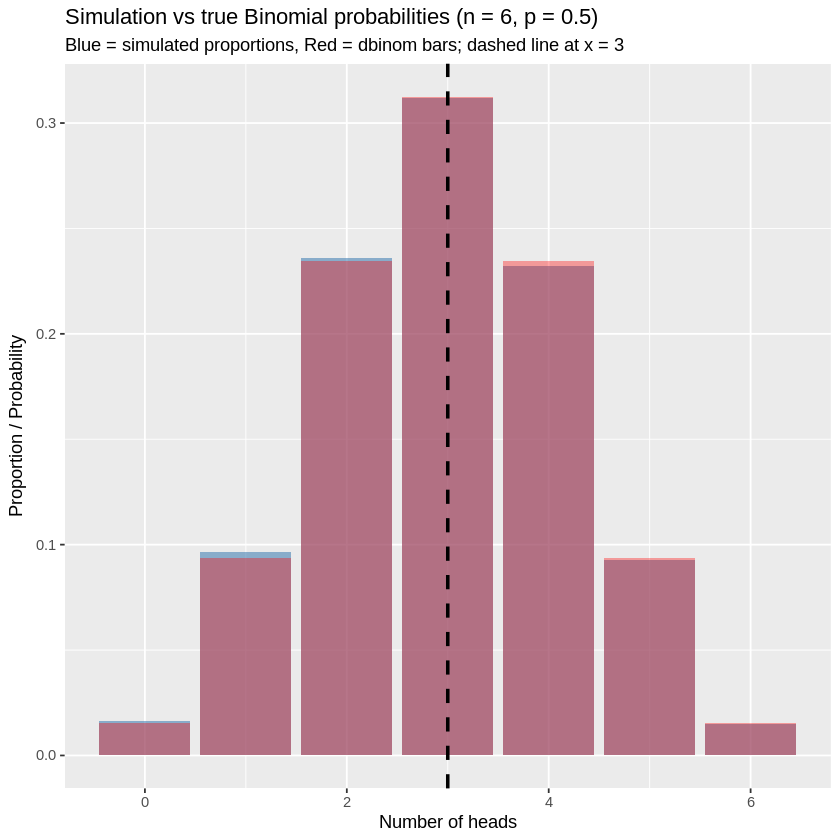

In [ ]:
n <- 6

true_df <- data.frame(
  heads = 0:n,
  true_prob = dbinom(0:n, size = n, prob = 0.5)
)

ggplot() +
  # simulation proportions (ggplot computes counts, then converts to prop)
  geom_bar(
    data = data,
    aes(x = heads, y = after_stat(prop)),
    fill = "steelblue",
    alpha = 0.6
  ) +
  # true probabilities as bars
  geom_col(
    data = true_df,
    aes(x = heads, y = true_prob),
    fill = "red",
    alpha = 0.35
  ) +
  geom_vline(xintercept = 3, linetype = "dashed", linewidth = 1) +
  labs(
    title = "Simulation vs true Binomial probabilities (n = 6, p = 0.5)",
    subtitle = "Blue = simulated proportions, Red = dbinom bars; dashed line at x = 3",
    x = "Number of heads",
    y = "Proportion / Probability"
  )


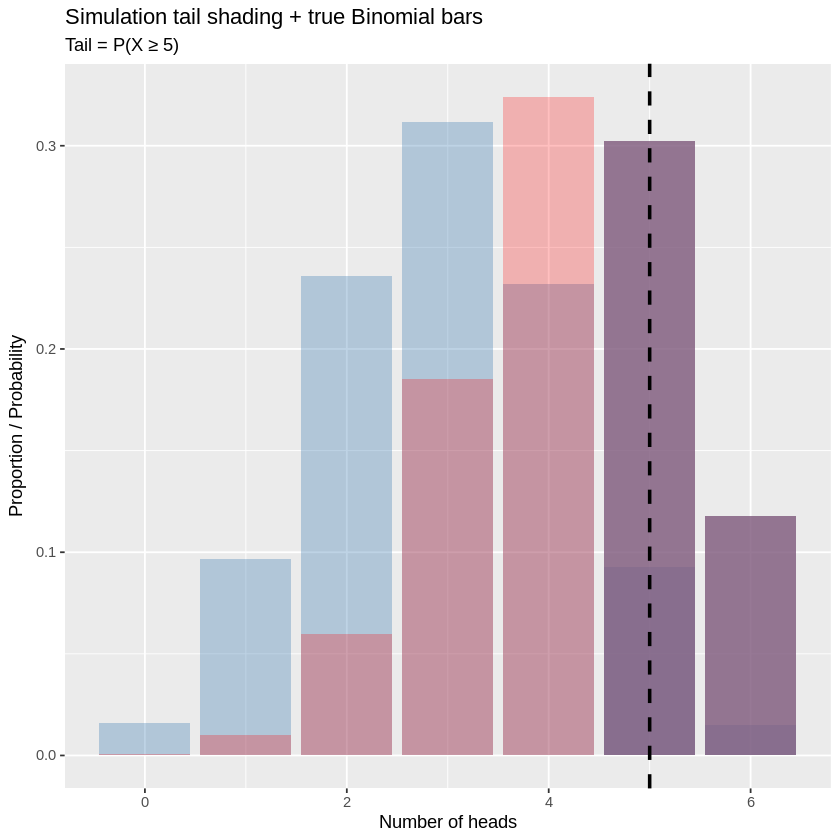

In [ ]:
true_df <- data.frame(
  heads = 0:n,
  true_prob = dbinom(0:n, size = n, prob = p)
)

ggplot() +
  # Simulation proportions (all bars, light)
  geom_bar(
    data = data,
    aes(x = heads, y = after_stat(prop)),
    fill = "steelblue",
    alpha = 0.35
  ) +
  # Simulation tail only (darker bars on top)
  geom_col(
    data = subset(true_df, heads >= 5),
    aes(x = heads, y = true_prob),
    fill = "steelblue",
    alpha = 0.75
  ) +
  # True probabilities as bars
  geom_col(
    data = true_df,
    aes(x = heads, y = true_prob),
    fill = "red",
    alpha = 0.25
  ) +
  geom_vline(xintercept = 5, linetype = "dashed", linewidth = 1) +
  labs(
    title = "Simulation tail shading + true Binomial bars",
    subtitle = paste0("Tail = P(X ≥ 5)"),
    x = "Number of heads",
    y = "Proportion / Probability"
  )


---

### End of demo
